#### Data: 28/05/25
---
---
# <center> **Naive Bayes**
---

## <center> **Projetos em Ciência de Dados**

#### <center> **Pós-Graduação - Instituto Mauá de Tecnologia**

#### <center> **VCP e Lucas Buk**
---
---


# **Bibliotecas**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

NLTK: https://www.nltk.org/

In [ ]:
%%capture

# Tratamento e limpeza de textos
import nltk
nltk.download('popular')

# **Teorema de Bayes**

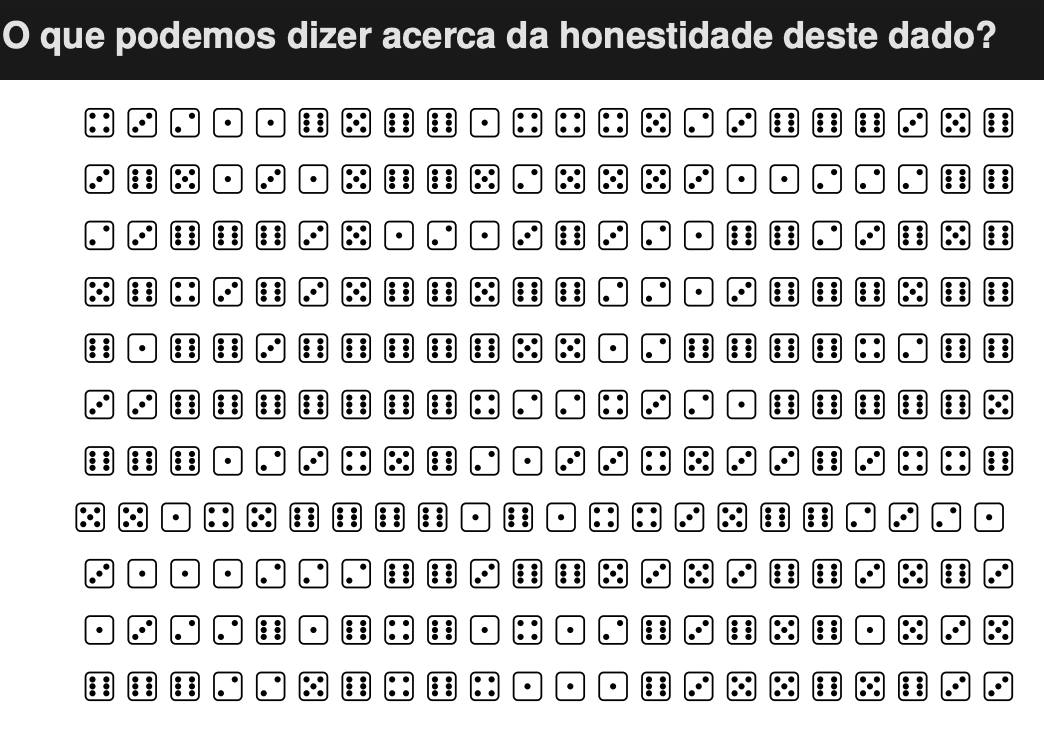

**Modelando o problema utilizando Bayes**





Podemos utilizar o **teorema de Bayes** para avaliar como cada dado novo atualiza a nossa crença acerca da sequência numérica. Neste sentido vamos modelar o problema, criando uma variável $k$ que pode assumir os valores $\mathbf{PAR}$ e $\mathbf{IMPAR}$ onde desejamos estimar a probabilidade $\theta$.



$P(\theta \vert k) = \frac{p(k \vert \theta) \; p(\theta)}{p(k)}$

Condições: $ k \in \{0,1\} \; e \; \theta \in [0,1].$

1.   Supondo que a probabilidade de termos um número **Par** seja representado por $p(\mathbf{PAR} \vert \theta)$.
2.   Supondo que a probabilidade de termos um número **Ímpar** seja representado por $p(\mathbf{IMPAR} \vert \theta) = 1 - p(\mathbf{PAR} \vert \theta)$.
3. Temos eventos independentes, logo: $p(\mathbf{PAR} \vert \theta) = \theta$ e $p(\mathbf{IMPAR} \vert \theta) = 1 - \theta$. Representando numericamente: $ \mathbf{PAR} = 1$ e $ \mathbf{IMPAR} = 0$.


Para a função de verossimilhança $p(k \vert \theta)$ podemos estabelecer, tendo em vista que trata-se de eventos independentes:

$p(k \vert \theta) = \theta^k (1 - \theta)^{(N-k)}$



**Definições importantes**



1.   $p(\theta):$ 'a priori' --> nossa crença acerca da 'honestidade' sem as evidências que desejamos analisar.
2.   $p(\theta \vert k):$ 'a posteriori' --> nossa crença atualizada por dados / eventos novos.
3.   $p(k \vert \theta):$ verossimilhança --> uma medida para avaliar o quanto um determinado $\theta$ representa o evento $k$.
4.   $p(k):$ representa uma 'medida' dos novos eventos --> evidência.




## **Funções**

In [ ]:
def moeda(PAR, N, k):

    P = PAR**k*(1-PAR)**(N-k)
    return P;

## **Crença: ou ele terá mais números ímpares ou números pares**

A função $Beta$ indica a função densidade de probabilidade de  $x$ no intervalo (0,1):
\begin{equation}
Beta(\alpha,\beta):\,\, prob(x|\alpha,\beta)=\frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}
\end{equation}

onde $B$ é a função $\beta$
\begin{equation}
B(\alpha,\beta)=\int_{0}^{1}t^{\alpha-1}(1-t)^{\beta-1}dt
\end{equation}

**Beta:** https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html

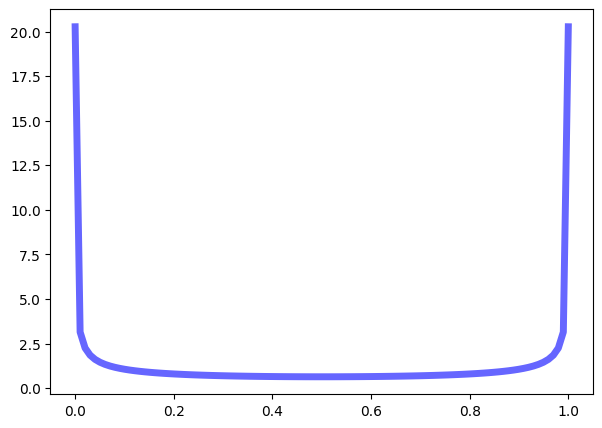

In [ ]:
from scipy.stats import beta

a, b = 0.5, 0.5
mean, var, skew, kurt = beta.stats(a, b, moments='mvsk')

plt.figure(figsize=(7, 5))

x1 = np.linspace(beta.ppf(0.01, a, b),
                 beta.ppf(0.99, a, b), 100)
plt.plot(x1, beta.pdf(x1, a, b),
         'b-', lw=5, alpha=0.6, label='beta pdf')

plt.show()

## **Crença: ele terá algo em torno de 50% de valores pares e 50% de valores ímpares**

**Distribuição Normal (Gaussiana)**

$$ p(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$

$$ F(x) = \frac{1}{2}\left[1 + \operatorname{erf}\left( \frac{x-\mu}{\sigma\sqrt{2}}\right)\right] $$

**Normal:** https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

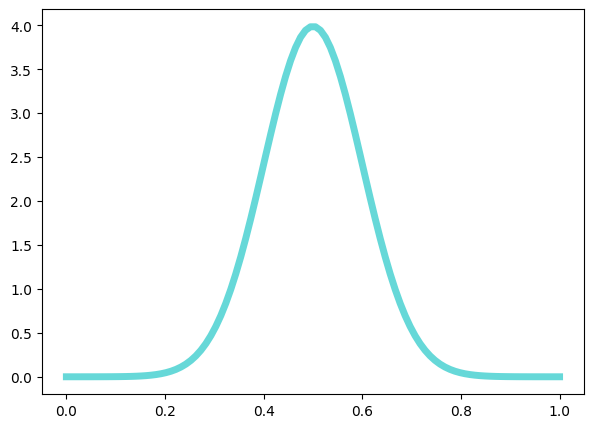

In [ ]:
from scipy.stats import norm

mean, var, skew, kurt = norm.stats(moments='mvsk')

plt.figure(figsize=(7, 5))

x2 = np.linspace(0, 1, 100)
plt.plot(x2, norm.pdf(x2, 0.5, 0.1),
         'c-', lw=5, alpha=0.6, label='norm pdf')

plt.show()

## **Crença: ele pode assumir qualquer proporção entre pares e ímpares**

**Distribuição uniforme**

$$f(x)=\begin{cases}
  \frac{1}{b - a} & \mathrm{for}\ a \le x \le b, \\[8pt]
  0 & \mathrm{for}\ x<a\ \mathrm{or}\ x>b
  \end{cases}$$

  $$ F(x)= \begin{cases}
  0 & \text{for }x < a \\[8pt]
  \frac{x-a}{b-a} & \text{for }a \le x \le b \\[8pt]
  1 & \text{for }x > b
  \end{cases}$$

  O primeiro momento - **media**:

  $$ E(X)=\frac{1}{2}(a+b) $$

  O segundo momento (central) - **variância**:

  $$ V(X)=\frac{1}{12}(b-a)^2 $$

**Uniforme:** https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html

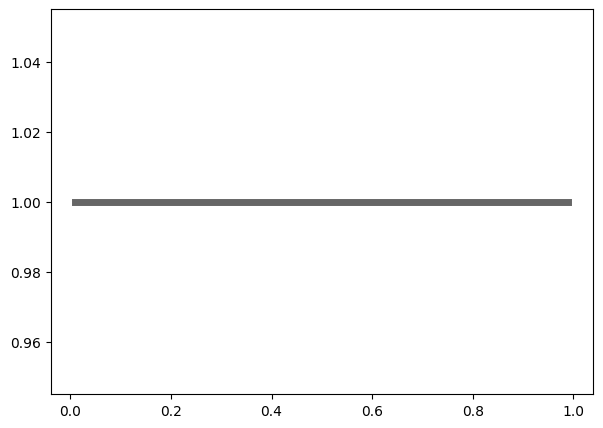

In [ ]:
from scipy.stats import uniform

mean, var, skew, kurt = uniform.stats(moments='mvsk')

plt.figure(figsize=(7, 5))

x3 = np.linspace(uniform.ppf(0.01), uniform.ppf(0.99), 100)
plt.plot(x3, uniform.pdf(x3), 'k-', lw=5,
         alpha=0.6, label='norm pdf')

plt.show()

## **Atualizando a crença**

In [ ]:
dados = np.array([4,3,2,1,1,6,5,6,6,1,4,4,4,5,2,3,6,6,6,3,5,6, # 22
                  3,6,5,1,3,1,5,6,6,5,2,5,5,5,3,1,1,2,2,2,6,6,
                  2,3,6,6,6,3,5,1,2,1,3,6,3,2,1,6,6,2,3,6,5,6,
                  5,6,4,3,6,3,5,6,6,5,6,6,2,2,1,3,6,6,6,5,6,6,
                  6,1,6,6,3,6,6,6,6,6,5,5,1,2,6,6,6,6,4,2,6,6,
                  3,3,6,6,6,6,6,6,6,4,2,2,4,3,2,1,6,6,6,6,6,5,
                  6,6,6,1,2,3,4,5,6,2,1,3,3,4,5,3,3,6,3,4,4,6,
                  5,5,1,4,5,6,6,6,6,1,6,1,4,4,3,5,6,6,2,3,2,1,
                  3,1,1,1,2,2,2,6,6,3,6,6,5,3,5,3,6,6,3,5,6,3,
                  1,3,2,2,6,1,6,4,6,1,4,1,2,6,3,6,5,6,1,5,3,5,
                  6,6,6,2,2,5,6,4,6,4,1,1,1,6,3,5,5,6,5,6,3,3])

<ipython-input-16-3e439aa3cf5b>:6: RuntimeWarning: invalid value encountered in multiply
  y1 = moeda(PAR,N,k)*beta.pdf(PAR, 0.5, 0.5)


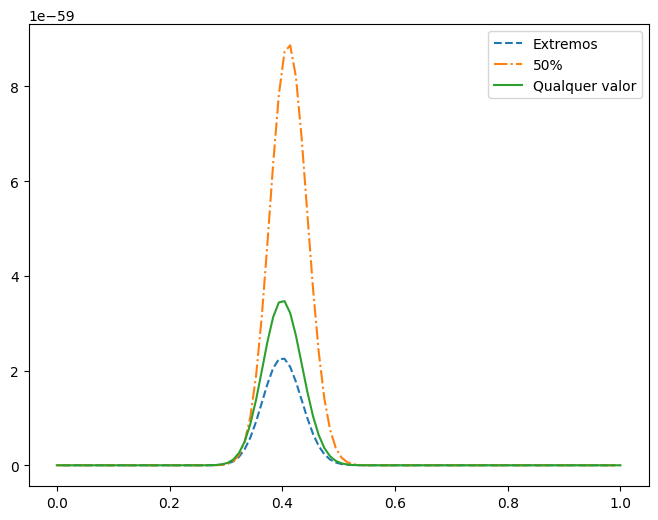

In [ ]:
PAR = np.linspace(0, 1, 100)

N = 200
k = 80

y1 = moeda(PAR,N,k)*beta.pdf(PAR, 0.5, 0.5)
y2 = moeda(PAR,N,k)*norm.pdf(PAR, 0.5, 0.1)
y3 = moeda(PAR,N,k)*uniform.pdf(PAR)

#### Visualização dos dados
plt.figure(figsize=(8, 6))
plt.plot(PAR, y1, linestyle='--', label='Extremos')
plt.plot(PAR, y2, linestyle='-.', label='50%')
plt.plot(PAR, y3, label='Qualquer valor')

plt.legend()
plt.show()

**Trazendo os dados para a realidade**

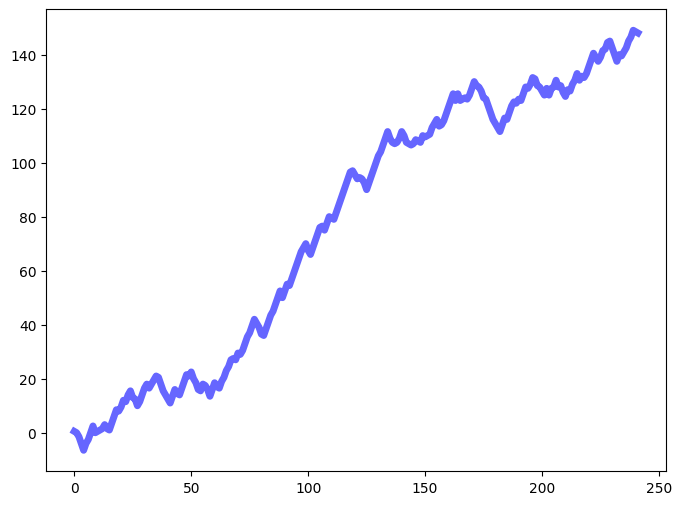

In [ ]:
# Calcula a tendência dos dados subtraindo 3.5 de cada valor em 'dados' e calculando a soma cumulativa.
# np.cumsum é uma função do NumPy que retorna a soma cumulativa dos elementos ao longo de um dado eixo.
tendencia = np.cumsum(dados - 3.5)

# Cria uma nova figura para a plotagem com tamanho especificado em polegadas.
plt.figure(figsize=(8,6))

# Plota a tendência calculada anteriormente.
# 'b-' indica uma linha azul, alpha=0.6 define a transparência da linha,
# lw=5 define a largura da linha, e label define o rótulo da linha que aparecerá na legenda.
plt.plot(tendencia, 'b-', alpha=0.6, lw=5, label='Tendência')

# Exibe a figura.
plt.show()

In [ ]:
def verificarDados(dados, N):
    # Inicializa a variável 'n' com 1 e a variável 'k' com 0.
    n = 1
    k = 0

    # Itera sobre cada elemento em 'dados'.
    for dado in dados:
        # Verifica se o elemento atual é par.
        if dado % 2 == 0:
            # Incrementa 'k' em 1 se o elemento for par.
            k += 1
            # Incrementa 'n' em 1.
            n += 1
        # Verifica se 'n' excede 'N'.
        if n > N:
            # Se 'n' for maior que 'N', sai do loop.
            break

    # Retorna o valor de 'k', que representa o número de elementos pares encontrados.
    return k

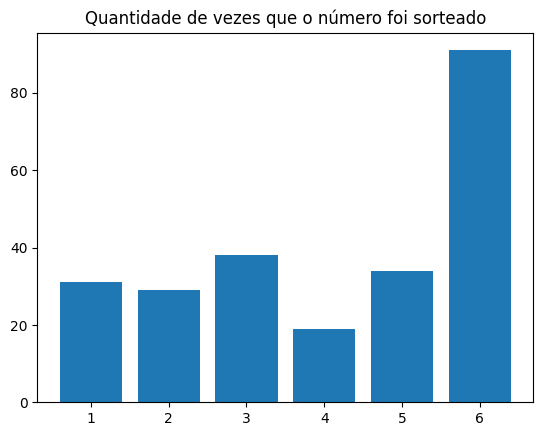

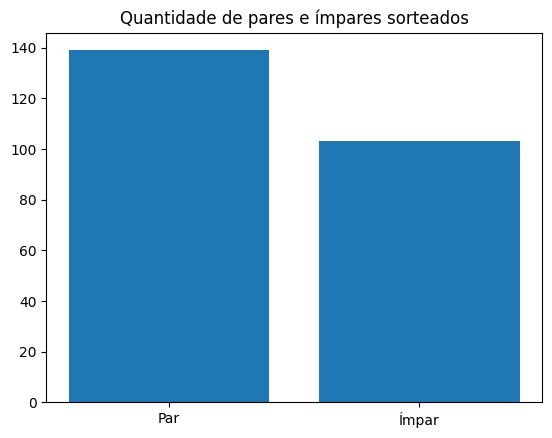

In [ ]:
# Inicializa contadores para cada número de 1 a 6.
n1 = n2 = n3 = n4 = n5 = n6 = 0

# Itera sobre cada elemento na lista 'dados'.
for dado in dados:
    # Verifica se o elemento é igual a 1 e incrementa 'n1' se for verdadeiro.
    if dado == 1:
        n1 += 1
    # Verifica se o elemento é igual a 2 e incrementa 'n2' se for verdadeiro.
    if dado == 2:
        n2 += 1
    # Verifica se o elemento é igual a 3 e incrementa 'n3' se for verdadeiro.
    if dado == 3:
        n3 += 1
    # Verifica se o elemento é igual a 4 e incrementa 'n4' se for verdadeiro.
    if dado == 4:
        n4 += 1
    # Verifica se o elemento é igual a 5 e incrementa 'n5' se for verdadeiro.
    if dado == 5:
        n5 += 1
    # Verifica se o elemento é igual a 6 e incrementa 'n6' se for verdadeiro.
    if dado == 6:
        n6 += 1

# Cria um gráfico de barras para mostrar a quantidade de vezes que cada número foi sorteado.
plt.bar([1, 2, 3, 4, 5, 6], [n1, n2, n3, n4, n5, n6])
plt.title('Quantidade de vezes que o número foi sorteado')
plt.show()

# Cria um gráfico de barras para mostrar a quantidade de números pares e ímpares sorteados.
plt.bar(['Par', 'Ímpar'], [n2 + n4 + n6, n1 + n3 + n5])
plt.title('Quantidade de pares e ímpares sorteados')
plt.show()

Observando a quantidade de vezes que os dados foram sorteados, é notavél que o número 6 se repete com uma frequência muito maior que os demais dados. Portanto, a crença mais próxima da realiade avaliada é que ele pode assumir qualquer proporção entre pares e ímpares.

# **Trabalhando com dados do Twitter**

In [ ]:
!gdown 17iQ0W3i6Qk_cylIaef2PfLZqJOFDfYhM --quiet

In [ ]:
df = pd.read_csv('/content/folha_tweets.csv')
print(df.shape)
df.head(3)

(3246, 6)


,id,created_at,text,likes,in reply to,retweeted
0,1323698685469958145,2020-11-03 18:48:54,"Eleitores formam longa fila, com distanciament...",86,folha,False
1,1323698217557676032,2020-11-03 18:47:02,"Maradona está melhor e quer sair do hospital, ...",40,NaN,False
2,1323698115178831883,2020-11-03 18:46:38,FBI investiga ligações automáticas que pedem a...,69,folha,False


**Limpando as mensagens**

In [ ]:
df['text'][0]

'Eleitores formam longa fila, com distanciamento físico, para votar em Oklahoma https://t.co/X68TUmOgQ9 https://t.co/YXf7yK1hE3'

In [ ]:
# Pacote para tratamento de expressões regulares
import re

# Retirando os termos do tipo: https://t.co/X68TUmOgQ9 https://t.co/YXf7yK1hE3
# Aplica uma função a cada elemento da coluna 'text' do DataFrame 'df_fsp'
# A função substitui (re.sub) padrões de texto que começam com '@' ou 'http'/'https'
# seguidos por qualquer caractere não-espacial (\S+) por uma string vazia ('')
df['text'] = df['text'].apply(lambda x: re.sub(r'(?:\@|https?\://)\S+', '', x))

# Exibe o primeiro elemento da coluna 'text' após a limpeza
df['text'][0]

'Eleitores formam longa fila, com distanciamento físico, para votar em Oklahoma  '

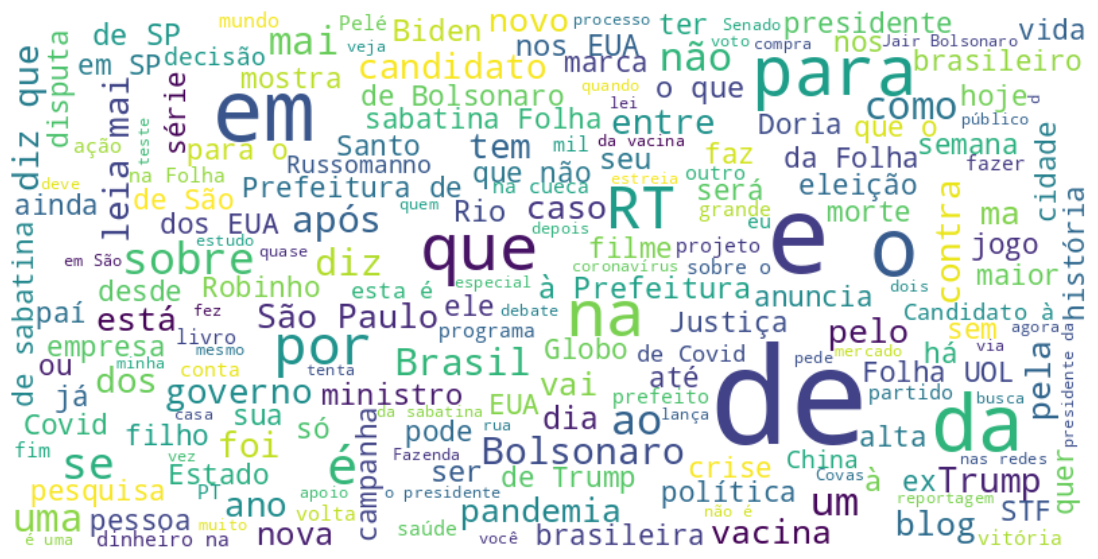

In [ ]:
from PIL import Image
from wordcloud import WordCloud, ImageColorGenerator

# Definição da coluna para a nuvem e junção de todos os reviews em um texto único
coluna_texto = df['text']

# Junta todos os reviews da coluna 'text' em uma única string, separando por espaço
reviews = ' '.join(review for review in coluna_texto)

# Criação da nuvem de palavras
# Configurações: tamanho máximo da fonte (max_font_size), número máximo de palavras (max_words)
# Cor de fundo (background_color), largura (width) e altura (height) da imagem
wordcloud = WordCloud(max_font_size=100, max_words=200, background_color='white',
                      width=800, height=400).generate(reviews)

# Configuração da figura
plt.figure(figsize=[15, 7])
# Exibição da nuvem de palavras com interpolação 'bilinear' para suavizar a imagem
plt.imshow(wordcloud, interpolation='bilinear')
# Remove os eixos da figura
plt.axis('off')
# Mostra a figura
plt.show()

## **Melhorando a limpeza**

**Minúsculo**

In [ ]:
def minusculo(frase):
    return frase.lower()

df['text'] = df['text'].apply(minusculo)

df['text'][0]

'eleitores formam longa fila, com distanciamento físico, para votar em oklahoma  '

**Tokenização**

In [ ]:
from nltk.tokenize import word_tokenize

df['text_token'] = [word_tokenize(frase) for frase in df['text']]

df['text_token'][0]

['eleitores',
 'formam',
 'longa',
 'fila',
 ',',
 'com',
 'distanciamento',
 'físico',
 ',',
 'para',
 'votar',
 'em',
 'oklahoma']

In [ ]:
df

,id,created_at,text,likes,in reply to,retweeted,text_token
0,1323698685469958145,2020-11-03 18:48:54,"eleitores formam longa fila, com distanciament...",86,folha,False,"[eleitores, formam, longa, fila, ,, com, dista..."
1,1323698217557676032,2020-11-03 18:47:02,"maradona está melhor e quer sair do hospital, ...",40,NaN,False,"[maradona, está, melhor, e, quer, sair, do, ho..."
2,1323698115178831883,2020-11-03 18:46:38,fbi investiga ligações automáticas que pedem a...,69,folha,False,"[fbi, investiga, ligações, automáticas, que, p..."
3,1323696678524882944,2020-11-03 18:40:55,"apesar de pandemia, trump fará festa da eleiçã...",44,folha,False,"[apesar, de, pandemia, ,, trump, fará, festa, ..."
4,1323687814085660672,2020-11-03 18:05:42,#eleicoes2020 eduardo bandeira de mello ( cand...,12,NaN,False,"[#, eleicoes2020, eduardo, bandeira, de, mello..."
...,...,...,...,...,...,...,...
3241,1316397358821920769,2020-10-14 15:16:02,joice versão kill bill e outras montagens veta...,99,NaN,False,"[joice, versão, kill, bill, e, outras, montage..."
3242,1316396103403737090,2020-10-14 15:11:03,cinesala lança vaquinha online de r$ 300 mil p...,16,NaN,False,"[cinesala, lança, vaquinha, online, de, r, $, ..."
3243,1316394841526480899,2020-10-14 15:06:02,disputa ideológica gera clima de tensão e até ...,21,NaN,False,"[disputa, ideológica, gera, clima, de, tensão,..."
3244,1316393336035565573,2020-10-14 15:00:03,portugal decreta estado de calamidade e aperta...,52,NaN,False,"[portugal, decreta, estado, de, calamidade, e,..."


**Remoção de StopWords**

In [ ]:
from nltk.corpus import stopwords

from string import punctuation

stw = stopwords.words('portuguese')

stw[:20]

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele']

In [ ]:
# Cria uma nova lista chamada stw_pt que combina a lista de palavras de parada (stw) com a lista de pontuação (punctuation)
stw_pt = list(stw + list(punctuation))

# Exibe as últimas 10 entradas da lista stw_pt
stw_pt[-10:]

['[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']

In [ ]:
stw_pt = stw_pt + ['rt']
stw_pt[-10:]

['\\', ']', '^', '_', '`', '{', '|', '}', '~', 'rt']

In [ ]:
def remover_stops(frase_token, stop_words):
    return [palavra for palavra in frase_token if palavra not in stop_words]

df['text_token_sem_stop'] = df['text_token'].apply(remover_stops, stop_words=stw_pt)

df['text_token_sem_stop'][0]

['eleitores',
 'formam',
 'longa',
 'fila',
 'distanciamento',
 'físico',
 'votar',
 'oklahoma']

In [ ]:
df['text_token'][0]

['eleitores',
 'formam',
 'longa',
 'fila',
 ',',
 'com',
 'distanciamento',
 'físico',
 ',',
 'para',
 'votar',
 'em',
 'oklahoma']

**Reconstruindo a frase**

In [ ]:
def reconstroi_frase(lista_palavras):
    return ' '.join(lista_palavras)

df['text_rec'] = df['text_token_sem_stop'].apply(reconstroi_frase)

df['text_rec'][0]

'eleitores formam longa fila distanciamento físico votar oklahoma'

In [ ]:
df['text_token_sem_stop'][0]

['eleitores',
 'formam',
 'longa',
 'fila',
 'distanciamento',
 'físico',
 'votar',
 'oklahoma']

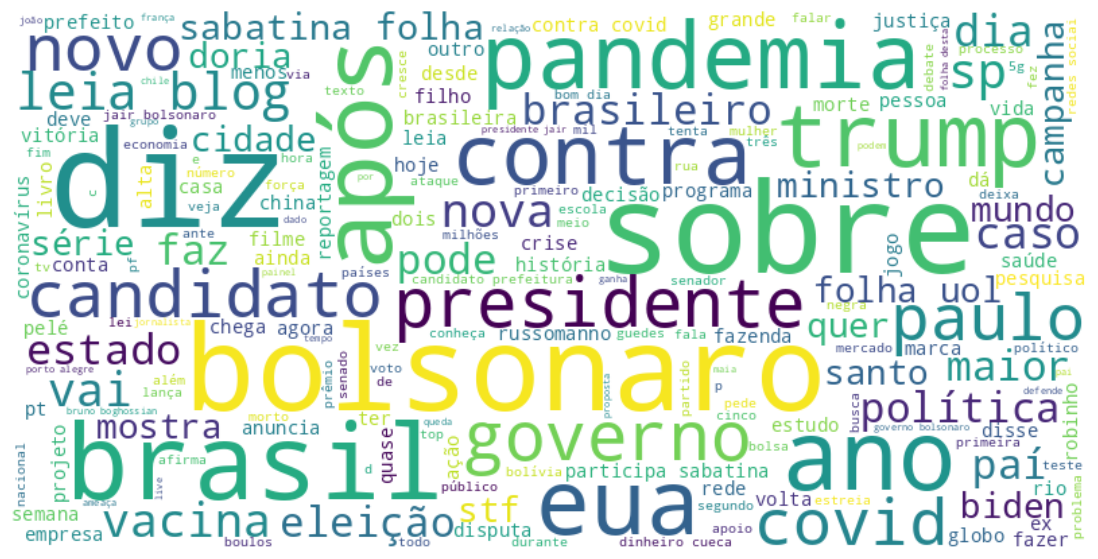

In [ ]:
from PIL import Image
from wordcloud import WordCloud, ImageColorGenerator

# Definição da coluna para a nuvem e junção de todos os reviews em um texto único
coluna_texto = df['text_rec']

# Junta todos os reviews da coluna 'text' em uma única string, separando por espaço
reviews = ' '.join(review for review in coluna_texto)

# Criação da nuvem de palavras
# Configurações: tamanho máximo da fonte (max_font_size), número máximo de palavras (max_words)
# Cor de fundo (background_color), largura (width) e altura (height) da imagem
wordcloud = WordCloud(max_font_size=100, max_words=200, background_color='white',
                      width=800, height=400).generate(reviews)

# Configuração da figura
plt.figure(figsize=[15, 7])
# Exibição da nuvem de palavras com interpolação 'bilinear' para suavizar a imagem
plt.imshow(wordcloud, interpolation='bilinear')
# Remove os eixos da figura
plt.axis('off')
# Mostra a figura
plt.show()

## **Criando os grupos de acordo com o número de likes**

In [ ]:
df.head(3)

,id,created_at,text,likes,in reply to,retweeted,text_token,text_token_sem_stop,text_rec
0,1323698685469958145,2020-11-03 18:48:54,"eleitores formam longa fila, com distanciament...",86,folha,False,"[eleitores, formam, longa, fila, ,, com, dista...","[eleitores, formam, longa, fila, distanciament...",eleitores formam longa fila distanciamento fís...
1,1323698217557676032,2020-11-03 18:47:02,"maradona está melhor e quer sair do hospital, ...",40,NaN,False,"[maradona, está, melhor, e, quer, sair, do, ho...","[maradona, melhor, quer, sair, hospital, diz, ...",maradona melhor quer sair hospital diz médico
2,1323698115178831883,2020-11-03 18:46:38,fbi investiga ligações automáticas que pedem a...,69,folha,False,"[fbi, investiga, ligações, automáticas, que, p...","[fbi, investiga, ligações, automáticas, pedem,...",fbi investiga ligações automáticas pedem eleit...


In [ ]:
lim = 60

df['label'] = [1 if x > lim else 0 for x in df['likes']]

df['label'].value_counts()

,count
label,
0,1892
1,1354


In [ ]:
df.head(3)

,id,created_at,text,likes,in reply to,retweeted,text_token,text_token_sem_stop,text_rec,label
0,1323698685469958145,2020-11-03 18:48:54,"eleitores formam longa fila, com distanciament...",86,folha,False,"[eleitores, formam, longa, fila, ,, com, dista...","[eleitores, formam, longa, fila, distanciament...",eleitores formam longa fila distanciamento fís...,1
1,1323698217557676032,2020-11-03 18:47:02,"maradona está melhor e quer sair do hospital, ...",40,NaN,False,"[maradona, está, melhor, e, quer, sair, do, ho...","[maradona, melhor, quer, sair, hospital, diz, ...",maradona melhor quer sair hospital diz médico,0
2,1323698115178831883,2020-11-03 18:46:38,fbi investiga ligações automáticas que pedem a...,69,folha,False,"[fbi, investiga, ligações, automáticas, que, p...","[fbi, investiga, ligações, automáticas, pedem,...",fbi investiga ligações automáticas pedem eleit...,1


# **Realizando filtragem e contagem de palavras**

**CountVectorizer:** https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
corpus = [df.text[0], df.text[1], df.text[2]]
corpus

['eleitores formam longa fila, com distanciamento físico, para votar em oklahoma  ',
 'maradona está melhor e quer sair do hospital, diz seu médico ',
 'fbi investiga ligações automáticas que pedem a eleitores que fiquem em casa no dia da eleição dos eua… ']

In [ ]:
vec = CountVectorizer()

X = vec.fit_transform(corpus)

In [ ]:
X.toarray()

array([[0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0],
       [1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 0]])

In [ ]:
vec.get_feature_names_out()

array(['automáticas', 'casa', 'com', 'da', 'dia', 'distanciamento', 'diz',
       'do', 'dos', 'eleitores', 'eleição', 'em', 'está', 'eua', 'fbi',
       'fila', 'fiquem', 'formam', 'físico', 'hospital', 'investiga',
       'ligações', 'longa', 'maradona', 'melhor', 'médico', 'no',
       'oklahoma', 'para', 'pedem', 'que', 'quer', 'sair', 'seu', 'votar'],
      dtype=object)

In [ ]:
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,automáticas,casa,com,da,dia,distanciamento,diz,do,dos,eleitores,...,médico,no,oklahoma,para,pedem,que,quer,sair,seu,votar
0,0,0,1,0,0,1,0,0,0,1,...,0,0,1,1,0,0,0,0,0,1
1,0,0,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,1,1,1,0
2,1,1,0,1,1,0,0,0,1,1,...,0,1,0,0,1,2,0,0,0,0


# **Classificando as mensagens da FSP**

In [ ]:
df.head(3)

,id,created_at,text,likes,in reply to,retweeted,text_token,text_token_sem_stop,text_rec,label
0,1323698685469958145,2020-11-03 18:48:54,"eleitores formam longa fila, com distanciament...",86,folha,False,"[eleitores, formam, longa, fila, ,, com, dista...","[eleitores, formam, longa, fila, distanciament...",eleitores formam longa fila distanciamento fís...,1
1,1323698217557676032,2020-11-03 18:47:02,"maradona está melhor e quer sair do hospital, ...",40,NaN,False,"[maradona, está, melhor, e, quer, sair, do, ho...","[maradona, melhor, quer, sair, hospital, diz, ...",maradona melhor quer sair hospital diz médico,0
2,1323698115178831883,2020-11-03 18:46:38,fbi investiga ligações automáticas que pedem a...,69,folha,False,"[fbi, investiga, ligações, automáticas, que, p...","[fbi, investiga, ligações, automáticas, pedem,...",fbi investiga ligações automáticas pedem eleit...,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text_rec'],
                                                    df['label'],
                                                    test_size=0.2,
                                                    random_state=1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2596,), (650,), (2596,), (650,))

In [ ]:
X_train

,text_rec
2493,juca kfouri poucas vezes placar jogo exprime t...
169,hora reconhecer talentos chance desenvolver af...
359,'deserto creches montana caso extremo crise si...
108,sabatina arthur val erra sobre custo gabinete ...
1068,filmes temática lgbt ganham destaque mostra ci...
...,...
2763,direito navio r 55 mi cresce demanda megaiates...
905,moro defende prisão 2ª instância processos ini...
1096,série eleições grande sp hoje falo mogi cruzes...
235,antes robinho jogadores grêmio condenados abus...


In [ ]:
vectorizer = CountVectorizer(max_df=0.8, min_df=3)
vectorizer.fit(X_train)

X_train_vec = vectorizer.transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
X_train_vec.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
X_train_vec.shape, X_test_vec.shape

((2596, 2161), (650, 2161))

In [ ]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()

clf.fit(X_train_vec, y_train)

pred = clf.predict(X_test_vec)

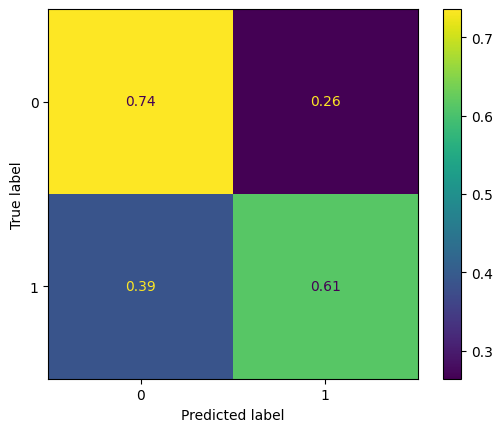

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test_vec, y_test,
                                      normalize='true')
plt.show()

# **Referências**

**Bayesian Inference of a Binomial Proportion:** https://www.quantstart.com/articles/Bayesian-Inference-of-a-Binomial-Proportion-The-Analytical-Approach/

**Teorema de Bayes**: https://didatica.tech/entenda-o-teorema-de-bayes/

**Classificador Naive Bayes**: https://towardsdatascience.com/naive-bayes-classifier-81d512f50a7c

**Naive Bayes scikit-learn**: https://scikit-learn.org/stable/modules/naive_bayes.html

**NLP**: https://www.deeplearning.ai/resources/natural-language-processing/

https://www.take.net/blog/tecnologia/nlp-processamento-linguagem-natural/
